In [10]:
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt

def unitary_product_with_ket_zero(pi_time, T, delta, t_wait_T):
    omega = np.pi / (pi_time * 1e-6)
    t_pi_over_2 = (pi_time * 1e-6) / 2

    def U1(omega, t):
        H = np.array([[0, omega / 2],
                      [omega / 2, delta]], dtype=complex)
        U = expm(-1j * H * t)
        return U

    def U_wait(omega, t):
        H = np.array([[0, 0],
                      [0, delta]], dtype=complex)
        U = expm(-1j * H * t)
        return U

    def U2(omega, t):
        H = np.array([[0, omega * np.exp(-1j * np.pi * (1+t_wait_T)) / 2],
                      [omega * np.exp(1j * np.pi * (1+t_wait_T)) / 2, delta]], dtype=complex)
        U = expm(-1j * H * t)
        return U

    U1 = U1(omega, t_pi_over_2)
    U_wait = U_wait(omega, T)
    U2 = U2(omega, t_pi_over_2)

    product = U2 @ U_wait @ U1

    ket_zero = np.array([1, 0], dtype=complex)
    result = product @ ket_zero
    # print(np.abs(result)**2)
    state_pop = np.abs(result)**2
    state_pop_0 = state_pop[0]
    return state_pop_0

# def unitary_product_with_ket_zero(pi_time, T, delta, t_wait_T):
#     omega = np.pi / (pi_time * 1e-6)
#     t_pi_over_2 = (pi_time * 1e-6) / 2

#     def U1(omega, t):
#         H = np.array([[0, omega / 2],
#                       [omega / 2, delta]], dtype=complex)
#         U = expm(-1j * H * t)
#         return U

#     def U_wait(omega, t):
#         H = np.array([[0, 0],
#                       [0, delta]], dtype=complex)
#         U = expm(-1j * H * t)
#         return U

#     def U2(omega, t):
#         H = np.array([[0, omega * np.exp(-1j *  np.pi * t_wait_T) / 2],
#                       [omega * np.exp(1j *  np.pi * t_wait_T) / 2, delta]], dtype=complex)
#         U = expm(-1j * H * t)
#         return U

#     U1 = U1(omega, t_pi_over_2)
#     U_wait = U_wait(omega, 2*T)
#     U2 = U2(omega, t_pi_over_2)

#     product = U2 @ U_wait @ U1

#     ket_zero = np.array([1, 0], dtype=complex)
#     result = product @ ket_zero
#     state_pop = np.abs(result)**2
#     return state_pop

def call_unitary_product_twice(pi_time, T, delta):
    result1 = unitary_product_with_ket_zero(pi_time, T, delta, 1/2)
    result2 = unitary_product_with_ket_zero(pi_time, T, delta, 3/2)
    return result1, result2

# Example usage
pi_time = 24.16
T = 250e-6
delta = 400*np.pi*2
print(delta)
result1, result2 = call_unitary_product_twice(pi_time, T, delta)

print("State population with t_wait_T = 1/4:")
print(result1)
print("State population with t_wait_T = 3/4:")
print(result2)

2513.2741228718346
State population with t_wait_T = 1/4:
0.19069441702165996
State population with t_wait_T = 3/4:
0.8093055894050237


-2513.2741228718414
Optimized delta value:
-400.0000000000011


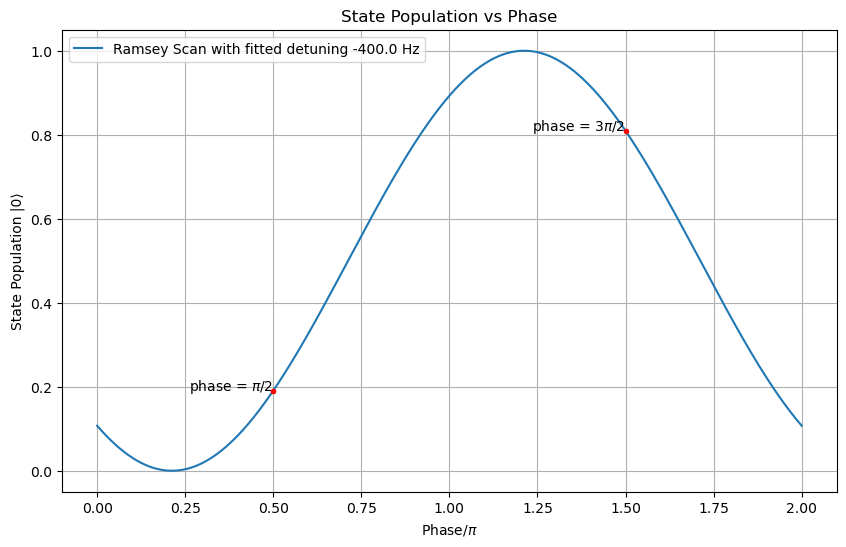

In [11]:
import numpy as np
from scipy.linalg import expm
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def unitary_product_with_ket_zero(pi_time, T, delta, t_wait_T):
    omega = np.pi / (pi_time * 1e-6)
    t_pi_over_2 = (pi_time * 1e-6) / 2

    def U1(omega, t):
        H = np.array([[0, omega / 2],
                      [omega / 2, delta]], dtype=complex)
        U = expm(-1j * H * t)
        return U

    def U_wait(omega, t):
        H = np.array([[0, 0],
                      [0, delta]], dtype=complex)
        U = expm(-1j * H * t)
        return U

    def U2(omega, t):
        H = np.array([[0, omega * np.exp(-1j *  np.pi * (t_wait_T)) / 2],
                      [omega * np.exp(1j *  np.pi * (t_wait_T)) / 2, delta]], dtype=complex)
        U = expm(-1j * H * t)
        return U

    U1 = U1(omega, t_pi_over_2)
    U_wait = U_wait(omega, T)
    U2 = U2(omega, t_pi_over_2)

    product = U2 @ U_wait @ U1

    ket_zero = np.array([1, 0], dtype=complex)
    result = product @ ket_zero
    state_pop = np.abs(result)**2
    return state_pop[0]

def call_unitary_product_twice(pi_time, T, delta):
    result1 = unitary_product_with_ket_zero(pi_time, T, delta, 1/2)
    result2 = unitary_product_with_ket_zero(pi_time, T, delta, 3/2)
    return result1, result2

def fitting_function(delta, pi_time, T, target_results):
    computed_result1, computed_result2 = call_unitary_product_twice(pi_time, T, delta[0])
    target_result1, target_result2 = target_results
    error = (computed_result1 - target_result1)**2 + (computed_result2 - target_result2)**2
    return error

# Example usage
pi_time = 24.16
T = 250e-6
initial_delta_guess = [100 * 2 * np.pi]
# result1 =  0.28
# result2 = 0.73
target_results = (result1 , result2)  # Example target results, replace with actual target results

result = minimize(fitting_function, initial_delta_guess, args=(pi_time, T, target_results),method='Nelder-Mead')
optimized_delta = result.x[0]
print(optimized_delta)
print("Optimized delta value:")
print(optimized_delta/(2*np.pi))

# Plotting the results
t_wait_T_values = np.linspace(0, 2, 500)
state_populations = [unitary_product_with_ket_zero(pi_time, T, optimized_delta, t_wait_T) for t_wait_T in t_wait_T_values]

plt.figure(figsize=(10, 6))
plt.plot(t_wait_T_values, state_populations, label=f'Ramsey Scan with fitted detuning {np.round(optimized_delta/(2*np.pi))} Hz')

# Marking the target points
plt.scatter([1/2, 3/2], target_results, color='red', zorder=5,marker = '.')
plt.text(1/2, target_results[0], 'phase = ${\pi / 2}$', fontsize=10, ha='right')
plt.text(3/2, target_results[1], 'phase = ${3\pi / 2}$', fontsize=10, ha='right')

plt.xlabel('Phase/$\pi$')
plt.ylabel('State Population |0⟩')
plt.title('State Population vs Phase')
plt.legend()
plt.grid(True)
plt.savefig('example_fast_calibration.png',dpi = 300)
plt.show()